# 04 · The social cost of changing your mind

A focused experiment on the paper's §3.2 claim: the complexity term in
the variational free energy is a *motivational cost of mind-change*,
parameterised by $\lambda \geq 0$ in the asymmetric-KL update

$$
C^{(t+1)} \;=\; \arg\min_{C} \left[\, \mathrm{KL}\!\bigl(q^{(t+1)} \,\Vert\, p_C\bigr) \;+\; \lambda \cdot \mathrm{KL}\!\bigl(p_C \,\Vert\, p_{C^{(t)}}\bigr)\,\right].
$$

At $\lambda = 0$ the agent freely projects every new posterior onto $C$
— Bayes-optimal, no resistance. As $\lambda \to \infty$, $C$ is frozen.
Intermediate $\lambda$ is *stubbornness*: the agent updates but pays a
cost, and that cost shows up as **path-dependence under environmental
reversal** (Proposition 1).

**This notebook** isolates the multi-agent prediction: when you embed
the same $\lambda$-gated update inside a social network with delegation
$d > 0$, the network *itself* becomes a source of variational cost —
recursive averaging gives the group a memory that no individual carries.
The headline result is a 2-D map of lock-in over $(\lambda, d)$.

## §0 · How we measure lock-in

We drive `env.s_star[0]` through a deterministic shock:

  warmup at $0$ (let beliefs settle) → shock to $1$ for `leg_T` steps
  (forward) → shock back to $0$ for `leg_T` steps (reverse).

At three checkpoints we read off the population-mean preference
$\bar{\sigma}(C) = \frac{1}{N} \sum_i \sigma(C_i)$:

- $\bar\sigma_0$ — end of warmup, baseline.
- $\bar\sigma_+$ — end of forward leg (peak response to shock).
- $\bar\sigma_-$ — end of reverse leg (after env has been restored).

From these we report two complementary numbers:

| name | formula | reads as |
|---|---|---|
| **shock response** $A$ | $\bar\sigma_+ - \bar\sigma_0$ | how much the shock *moved* the agent. $A \to 0$ means complete rigidity. |
| **endpoint residual** $R$ | $\bar\sigma_- - \bar\sigma_0$ | how much of the shock remains after reversal. $R \to 0$ means full recovery (or no engagement to begin with). |

Reporting both disambiguates the two ways $R$ can be small: $A$ large &
$R$ small = flexible agent; $A$ small & $R$ small = unresponsive agent.
Genuine lock-in is the regime where $A$ is *large and* $R$ is large.

The unitless ratio $R/A$ — the **lock-in fraction** — is the cleanest
single number when both costs are present, ranging from $0$ (fully
reversible) to $1$ (the shock is permanent).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax.numpy as jnp
import equinox as eqx

from src import build, ModelConfig, EnvConfig, EvolutionRegime

sns.set_theme(context='notebook', style='whitegrid')


def isolate(pop):
    return eqx.tree_at(lambda p: p.d, pop, jnp.zeros_like(pop.d))


def run_shock_cycle(lambda_val: float, *,
                    n_agents: int = 50, warm_T: int = 30, leg_T: int = 20,
                    d_mean: float | None = None,
                    gamma_env: float = 4.0, seed: int = 0):
    """Run one forward-reverse shock cycle. Returns (sig_traj, x_traj, marks).

    ``marks`` is dict with step indices ``warm_end``, ``fwd_end``, ``rev_end``
    so the metrics can index directly without re-deriving leg boundaries.
    """
    if d_mean is None:
        d_a, d_b = 0.1, 100.0      # placeholder; isolate() overrides
    else:
        d_a = max(0.5, 10.0 * d_mean)
        d_b = max(0.5, 10.0 * (1.0 - d_mean))

    cfg = ModelConfig(
        n_agents=n_agents, n_features=1,
        lambda_dist=('constant', {'value': float(lambda_val)}),
        lambda_scope='per_agent',
        gamma_env=gamma_env,
        delegation_alpha=d_a, delegation_beta=d_b,
        network_kind='watts_strogatz', mean_degree=4, rewiring_p=0.1,
        seed=seed,
    )
    env_cfg = EnvConfig(
        n_agents=n_agents, n_features=1,
        regime=EvolutionRegime.STATIONARY, stationary_flip_prob=0.0,
        seed=seed + 100,
    )
    env, pop = build(cfg, env_cfg)
    if d_mean is None:
        pop = isolate(pop)

    env.s_star[:] = np.array([0], dtype=np.int64)
    sigs, xs = [], []

    def rec(x: int) -> None:
        sigs.append(1.0 / (1.0 + np.exp(-np.asarray(pop.C)[:, 0])))
        xs.append(x)

    rec(0)
    for _ in range(warm_T):
        pop, _ = pop.step(env); rec(0)
    warm_end = len(sigs) - 1
    env.s_star[0] = 1
    for _ in range(leg_T):
        pop, _ = pop.step(env); rec(1)
    fwd_end = len(sigs) - 1
    env.s_star[0] = 0
    for _ in range(leg_T):
        pop, _ = pop.step(env); rec(0)
    rev_end = len(sigs) - 1

    return (np.stack(sigs), np.array(xs, dtype=float),
            dict(warm_end=warm_end, fwd_end=fwd_end, rev_end=rev_end))


def lock_in_metrics(sigs: np.ndarray, marks: dict) -> dict:
    """sigs : (T, N). Returns shock response A, endpoint residual R, ratio."""
    pop_mean = sigs.mean(axis=1)
    s0 = pop_mean[marks['warm_end']]
    sp = pop_mean[marks['fwd_end']]
    sm = pop_mean[marks['rev_end']]
    A = sp - s0
    R = sm - s0
    frac = R / A if abs(A) > 1e-6 else 0.0
    return dict(baseline=s0, fwd_peak=sp, rev_end=sm,
                response=A, residual=R, lock_in_frac=float(frac))


## §1 · Brief lead-in — what the metric looks like for an isolated mind

Three $\lambda$ values, $d = 0$ (social channel disabled). The left
panel shows the $\sigma(C)$ timeseries with $\bar\sigma_0$, $\bar\sigma_+$,
$\bar\sigma_-$ marked. The right panel reports the metric trio.

- $\lambda = 0$: $A \approx 1$ (full response), $R \approx 0$ (fully recovers). No lock-in.
- $\lambda = 5$: partial response, partial residual. Lock-in fraction is the residual divided by the response.
- $\lambda = 100$: $A \approx 0$ (barely engaged), $R \approx 0$. The lock-in fraction is undefined/meaningless here — the agent didn't move.

This is the single-agent baseline. §2 puts the same metric on a (λ, d)
grid where the *social* contribution to lock-in becomes visible.

c:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:60: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


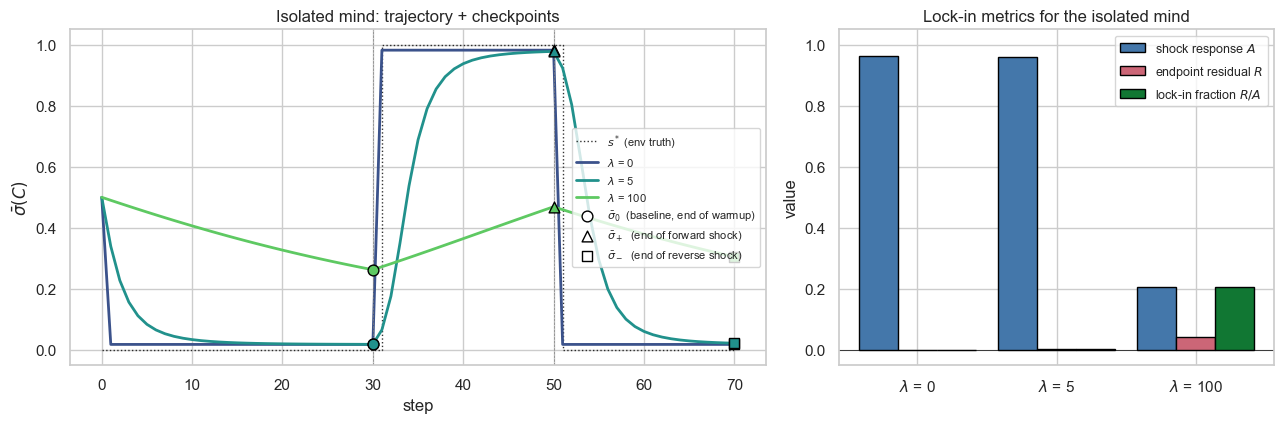

  lambda |  A (response) |  R (residual) |  R/A (lock-in)
----------------------------------------------------------
       0 |         0.964 |         0.000 |          0.000
       5 |         0.960 |         0.004 |          0.004
     100 |         0.206 |         0.042 |          0.205


In [2]:
warm_T, leg_T = 30, 20
LAMBDAS_LEAD = [0.0, 5.0, 100.0]
LEAD_COLOURS = sns.color_palette('viridis', n_colors=len(LAMBDAS_LEAD))

lead = {}
for lam in LAMBDAS_LEAD:
    sigs, xs, marks = run_shock_cycle(
        lam, n_agents=8, warm_T=warm_T, leg_T=leg_T, d_mean=None,
    )
    lead[lam] = (sigs, xs, marks, lock_in_metrics(sigs, marks))

fig, (ax_t, ax_b) = plt.subplots(1, 2, figsize=(13, 4.4),
                                 gridspec_kw={'width_ratios': [1.6, 1.0]})

# Left: trajectories with checkpoint markers
xs_ref = lead[LAMBDAS_LEAD[0]][1]
steps = np.arange(len(xs_ref))
ax_t.step(steps, xs_ref, where='post', color='black', ls=':', lw=1.0,
          alpha=0.8, label='$s^*$ (env truth)')
for col, lam in zip(LEAD_COLOURS, LAMBDAS_LEAD):
    sigs, _, marks, m = lead[lam]
    y = sigs.mean(axis=1)
    ax_t.plot(steps, y, color=col, lw=2.0, label=f'$\\lambda$ = {lam:g}')
    for k, marker in [('warm_end', 'o'), ('fwd_end', '^'), ('rev_end', 's')]:
        ax_t.scatter([marks[k]], [y[marks[k]]], color=col,
                     edgecolor='black', s=60, marker=marker, zorder=5)
# Legend entries for the marker shapes (one black marker each)
ax_t.scatter([], [], color='white', edgecolor='black', s=60, marker='o',
             label=r'$\bar\sigma_0$  (baseline, end of warmup)')
ax_t.scatter([], [], color='white', edgecolor='black', s=60, marker='^',
             label=r'$\bar\sigma_+$  (end of forward shock)')
ax_t.scatter([], [], color='white', edgecolor='black', s=60, marker='s',
             label=r'$\bar\sigma_-$  (end of reverse shock)')
ax_t.axvline(marks['warm_end'], ls='--', c='grey', lw=0.5)
ax_t.axvline(marks['fwd_end'],  ls='--', c='grey', lw=0.5)
ax_t.set(xlabel='step', ylabel=r'$\bar{\sigma}(C)$', ylim=(-0.05, 1.05),
         title='Isolated mind: trajectory + checkpoints')
ax_t.legend(loc='center right', fontsize=8)

# Right: metric bars per lambda
xpos = np.arange(len(LAMBDAS_LEAD))
bw = 0.28
A_vals = [lead[l][3]['response'] for l in LAMBDAS_LEAD]
R_vals = [lead[l][3]['residual'] for l in LAMBDAS_LEAD]
F_vals = [lead[l][3]['lock_in_frac'] for l in LAMBDAS_LEAD]
ax_b.bar(xpos - bw, A_vals, bw, color='#4477AA', edgecolor='black',
         label='shock response $A$')
ax_b.bar(xpos,       R_vals, bw, color='#CC6677', edgecolor='black',
         label='endpoint residual $R$')
ax_b.bar(xpos + bw,  F_vals, bw, color='#117733', edgecolor='black',
         label='lock-in fraction $R/A$')
ax_b.set(xticks=xpos, xticklabels=[f'$\\lambda$ = {l:g}' for l in LAMBDAS_LEAD],
         ylabel='value', ylim=(-0.05, 1.05),
         title='Lock-in metrics for the isolated mind')
ax_b.axhline(0, color='black', lw=0.5)
ax_b.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'lambda':>8} | {'A (response)':>13} | {'R (residual)':>13} | {'R/A (lock-in)':>14}")
print('-' * 58)
for lam in LAMBDAS_LEAD:
    m = lead[lam][3]
    print(f"{lam:>8g} | {m['response']:>13.3f} | {m['residual']:>13.3f} | {m['lock_in_frac']:>14.3f}")


## §2 · The social variational cost — sweep over $(\lambda, d)$

Now the headline result. We run the same shock cycle on $N = 80$ agents
wired in a Watts–Strogatz network, varying:

- **individual rigidity** $\lambda \in \{0, 0.5, 1, 2, 5, 10, 25, 50, 100, 200\}$
- **social delegation** $d \in \{0, 0.3, 0.6, 0.9\}$  (mean of a Beta(10$\mu$, 10(1$-\mu$)) prior)

For each $(\lambda, d)$ we read off the metric trio. The story that
should land:

1. **The network has a memory even when individuals don't.** At
   $\lambda = 0, d = 0.9$ the residual $R$ is large despite every agent
   being Bayes-optimal — recursive social averaging is a lag.
2. **Lock-in fraction is the natural common axis.** Both $\lambda$ and
   $d$ push $R/A$ upward; they are substitutable along an iso-lock-in
   ridge.
3. **High-$\lambda$ + low-$d$ rigidity is "blind"**: $A$ is small, so
   even if $R/A$ looks moderate it reflects almost no engagement. The
   $A$ heatmap distinguishes these regimes from genuine social lock-in.

c:\GitHub\Paradigm_Shift_Act_Inf\src\population.py:60: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return PymdpAgent(A=A, B=B, C=C, D=D, batch_size=N, num_iter=1)


2-D sweep (10 λ × 4 d) ran in 64.2s


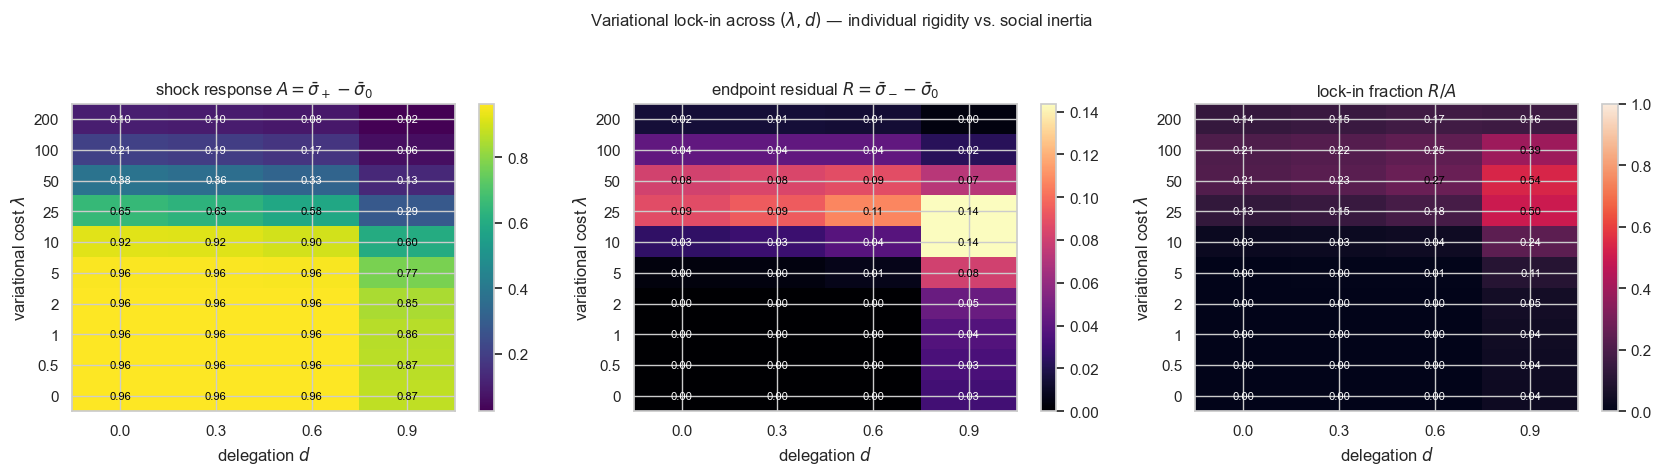

In [3]:
import time

lam_grid = np.array([0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0])
d_grid   = [0.0, 0.3, 0.6, 0.9]

response_2d = np.zeros((len(lam_grid), len(d_grid)))
residual_2d = np.zeros_like(response_2d)
fraction_2d = np.zeros_like(response_2d)

t0 = time.perf_counter()
for li, lam in enumerate(lam_grid):
    for di, dm in enumerate(d_grid):
        sigs, xs, marks = run_shock_cycle(
            lam, n_agents=80, warm_T=warm_T, leg_T=leg_T,
            d_mean=(None if dm == 0.0 else dm),
        )
        m = lock_in_metrics(sigs, marks)
        response_2d[li, di] = m['response']
        residual_2d[li, di] = m['residual']
        fraction_2d[li, di] = m['lock_in_frac']
print(f'2-D sweep ({len(lam_grid)} λ × {len(d_grid)} d) ran in {time.perf_counter()-t0:.1f}s')


def annotated_heatmap(ax, M, title, cmap='viridis', vmin=None, vmax=None):
    im = ax.imshow(M, aspect='auto', origin='lower', cmap=cmap,
                   vmin=vmin, vmax=vmax)
    ax.set(xticks=np.arange(len(d_grid)),
           xticklabels=[f'{d:.1f}' for d in d_grid],
           yticks=np.arange(len(lam_grid)),
           yticklabels=[f'{l:g}' for l in lam_grid],
           xlabel='delegation $d$', ylabel='variational cost $\\lambda$',
           title=title)
    mid = 0.5 * (np.nanmax(M) + np.nanmin(M))
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center',
                    color='white' if M[i, j] < mid else 'black', fontsize=8)
    return im


fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
im1 = annotated_heatmap(axes[0], response_2d,
                        'shock response $A = \\bar\\sigma_+ - \\bar\\sigma_0$')
plt.colorbar(im1, ax=axes[0])
im2 = annotated_heatmap(axes[1], residual_2d,
                        'endpoint residual $R = \\bar\\sigma_- - \\bar\\sigma_0$',
                        cmap='magma')
plt.colorbar(im2, ax=axes[1])
im3 = annotated_heatmap(axes[2], fraction_2d,
                        'lock-in fraction $R/A$',
                        cmap='rocket', vmin=0, vmax=1)
plt.colorbar(im3, ax=axes[2])
fig.suptitle('Variational lock-in across $(\\lambda, d)$ — individual rigidity vs. social inertia',
             y=1.03, fontsize=12)
plt.tight_layout()
plt.show()


### Line plot: lock-in fraction vs $\lambda$ at each $d$

The heatmap shows the full surface; the line plot makes the substitution
visible. As $d$ rises, the lock-in fraction curve lifts and its rise
toward saturation happens at progressively *smaller* $\lambda$. In a
tightly-connected community (high $d$), an individual needs very little
rigidity to look fully locked-in from the outside.

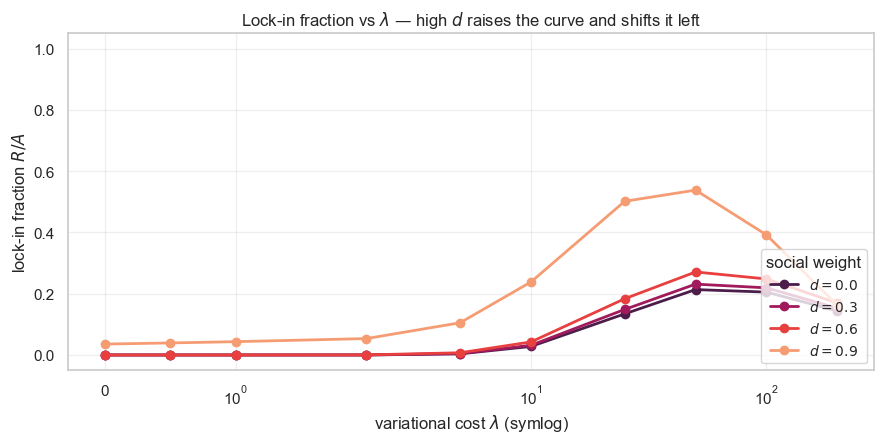

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.6))
d_colours = sns.color_palette('rocket', n_colors=len(d_grid))
for di, (dm, col) in enumerate(zip(d_grid, d_colours)):
    ax.plot(lam_grid, fraction_2d[:, di], marker='o', lw=2.0, color=col,
            label=f'$d = {dm:.1f}$')
ax.set(xscale='symlog', xlabel='variational cost $\\lambda$ (symlog)',
       ylabel='lock-in fraction $R/A$', ylim=(-0.05, 1.05),
       title='Lock-in fraction vs $\\lambda$ — high $d$ raises the curve and shifts it left')
ax.legend(loc='lower right', fontsize=10, title='social weight')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## What we've shown

1. **Lock-in is directly measurable from one shock cycle.** No
   phase-space gymnastics required: read $\bar\sigma$ at three
   checkpoints, take two differences. The residual $R$ is the cost
   paid in the asymmetric KL that doesn't reverse when the env does.

2. **Reporting $A$ alongside $R$ disambiguates rigidity from
   flexibility.** Both extremes give $R \approx 0$; only the $A$
   heatmap tells you which one. The combined ratio $R/A$ is the
   intuitive 0–1 "how stuck is the agent" number, valid wherever
   $A$ is non-trivial.

3. **Networks have a variational cost even when individuals don't.**
   At $\lambda = 0$, $d = 0.9$ the residual is substantial and the
   shock response is undiminished — the agents are individually
   Bayes-optimal but the *network* lags. This is the paper's §3.2
   prediction: social recursion is itself a complexity term.

4. **Individual and social costs substitute.** Iso-lock-in contours
   run diagonally across the $(\lambda, d)$ plane. In tightly-coupled
   groups, less individual stubbornness produces the same observable
   lock-in. The motivational cost of mind-change is paid jointly by
   the cognitive system and the social environment.